In [422]:
from FxFDrive import FxFDrive, make_can_bus, list_available_drives, bytes_to_int, int_to_bytes
from FxFDrive import DriveError, DriveState
import time
import numpy as np
from matplotlib import pyplot as plt

In [423]:
print("Starting can bus")
bus = make_can_bus()
motor = FxFDrive(bus, 10)
print("Started...")

Starting can bus
Started...


In [407]:
while(True):
    print(motor.telemetry.get_position_rads())
    time.sleep(0.1)

-2.862
-2.862
-2.862
-2.862
-2.862
-2.862
-2.862
-2.862
-2.862
-2.862
-2.862
-2.862


KeyboardInterrupt: 

In [424]:
motor.action.request_state_change(DriveState.drive_state_idle.value)

motor.set_parameter_int(motor.parameters.PARAM_KPV, 1_000, 3)
motor.set_parameter_int(motor.parameters.PARAM_KP, 1_000, 3)
motor.set_parameter_int(motor.parameters.PARAM_KV, 100, 3)
motor.set_parameter_int(motor.parameters.PARAM_MAXIMUM_MOTOR_CURRENT, 3_000, 2)

In [425]:
motor.action.request_state_change(DriveState.drive_state_impedance_control.value)
motor.action.send_position_target(3.0)

for i in range(100):
    print(motor.telemetry.get_motor_torque())
    time.sleep(0.1)

motor.action.request_state_change(DriveState.drive_state_idle.value)

651
2830
2904
3021
3033
2890
2866
3034
3093
2981
2894
3043
3037
3083
2924
3153
3072
2896
2907
2947
3048
2882
2142
438
-196
-743
-1942
-2512
-2852
-3205
-3178
-3013
-2964
-894
202
-296
-1982
-2922
-2943
-3046
-3269
-3065
-3052
-2813
-2793
-115
488
634
-157
-1307
-3278
-3155
-3138
-2596
-2875
-2624
-2896
-2767
-2672
818
521
191
402
913
822
1215
983
1278
1305
1397
1372
1320
1501
1469
1410
1389
1299
1378
1394
1465
1477
1417
1436
1452
1146
1344
1364
1361
1276
1458
1492
1352
1464
1370
1274
1497
1436
1305
1353
1297


In [421]:
motor.action.request_state_change(DriveState.drive_state_idle.value)

In [400]:
# motor.action.request_state_change(DriveState.drive_state_position_control.value)
motor.action.request_state_change(DriveState.drive_state_impedance_control.value)
motor.action.send_position_target(0.0)
motor.action.send_velocity_target(0.0)

time.sleep(0.5)

x = []

t = 0
for i in np.linspace(0, 1, 1500):
    t += 0.25 * i
    target = np.sin(t) * 5.0
    motor.action.send_position_target(target)
    current_position = motor.telemetry.get_position_rads()
    torque = motor.telemetry.get_motor_torque()
    vel = motor.telemetry.get_velocity_radsps()
    x.append([time.time(), target, current_position, target - current_position, torque, vel])
    time.sleep(0.005)

# input("shutdown")
motor.action.request_state_change(DriveState.drive_state_idle.value)

KeyboardInterrupt: 

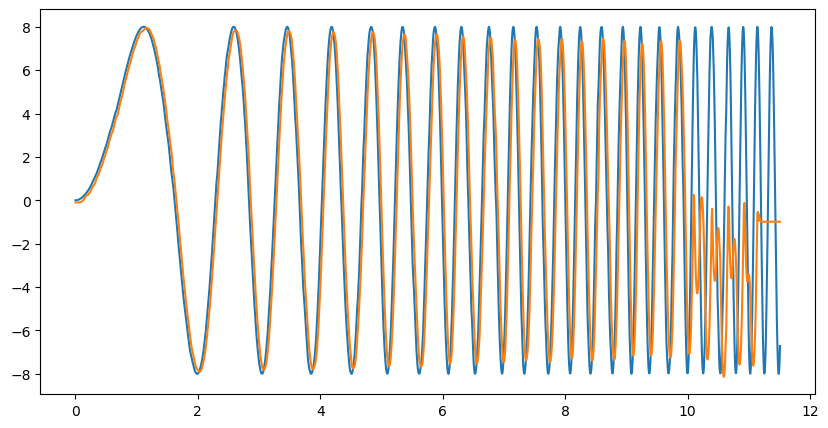

In [399]:
plt.figure(figsize=(10,5))

x = np.array(x)
# plt.subplot(3,1,1)
start = 0
end = -1
plt.plot(x[start:end, 0] - x[0, 0], x[start:end, 1])
plt.plot(x[start:end, 0] - x[0, 0], x[start:end, 2])

# plt.subplot(3,1,2)
# plt.plot(x[:, 2])

# plt.plot(x[:, 3])

# plt.subplot(3,1,3)
# plt.plot(x[:, 4])

In [214]:
bus.shutdown()